In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('datasetw.csv')

In [3]:
df.columns

Index(['mean_x', 'mean_y', 'mean_z', 'mean_mag', 'std_x', 'std_y', 'std_z',
       'std_mag', 'var_x', 'var_y', 'var_z', 'var_mag', 'range_x', 'range_y',
       'range_z', 'range_mag', 'max_x', 'max_y', 'max_z', 'max_mag', 'min_x',
       'min_y', 'min_z', 'min_mag', 'q25_mag', 'q50_mag', 'q75_mag', 'cv_mag',
       'rms_x', 'rms_y', 'rms_z', 'rms_mag', 'mean_jerk', 'std_jerk',
       'max_jerk', 'min_jerk', 'sma', 'zcr_x', 'zcr_y', 'zcr_z', 'zcr_mag',
       'energy_x', 'energy_y', 'energy_z', 'energy_mag', 'dominant_power',
       'spectral_energy', 'power_tremor_band', 'power_low_freq',
       'power_mid_freq', 'power_high_freq', 'spectral_entropy',
       'spectral_centroid', 'spectral_spread', 'freeze_index',
       'locomotor_power', 'freeze_power', 'cadence_spm', 'step_regularity',
       'freeze_ratio', 'steps_10s', 'numSamples', 'label'],
      dtype='object')

Unique values in label:
['gait_slow' 'gait_normal' 'gait_fast']

Count by gait type:
label
gait_slow      40
gait_normal    40
gait_fast      40
Name: count, dtype: int64

Statistics of steps_10s by type:
             count   mean       std   min   25%   50%   75%   max
label                                                            
gait_fast     40.0  17.10  2.753087  14.0  16.0  16.0  18.0  26.0
gait_normal   40.0  14.65  2.326547  10.0  14.0  14.0  16.0  24.0
gait_slow     40.0  12.70  2.766095   8.0  11.0  12.0  14.0  20.0

Grouped data:
label
gait_fast      17.10
gait_normal    14.65
gait_slow      12.70
Name: steps_10s, dtype: float64


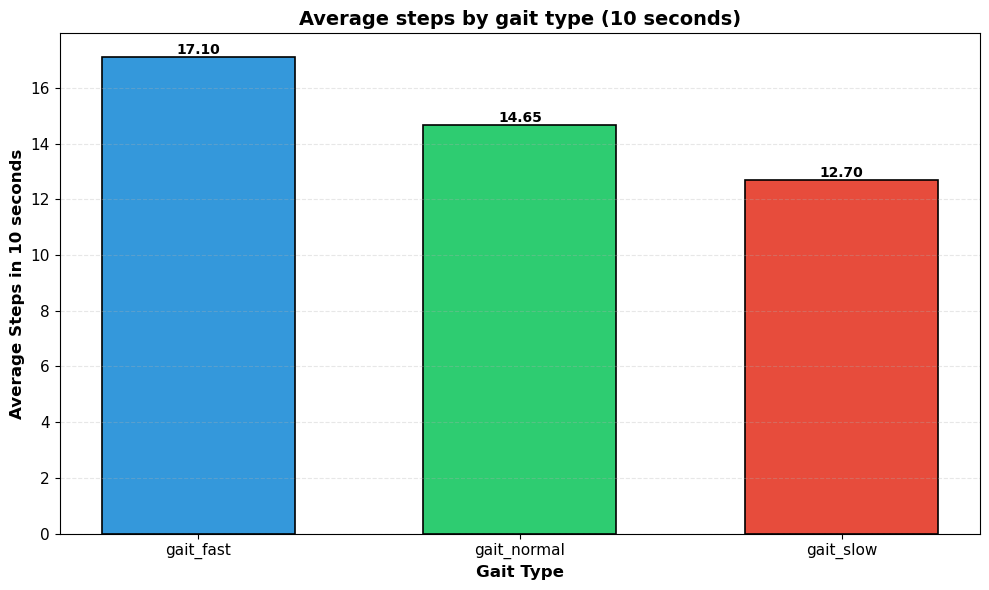

In [4]:
# First check unique values in label
print("Unique values in label:")
print(df['label'].unique())
print("\nCount by gait type:")
print(df['label'].value_counts())
print("\nStatistics of steps_10s by type:")
print(df.groupby('label')['steps_10s'].describe())

# Clean data: remove NaN and infinite values
df_clean = df[['label', 'steps_10s']].copy()
df_clean = df_clean.dropna()
df_clean = df_clean[~df_clean['steps_10s'].isin([float('inf'), float('-inf')])]

# Group data by gait type
grouped_data = df_clean.groupby('label')['steps_10s'].mean()

print("\nGrouped data:")
print(grouped_data)

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']  # Blue for slow, green for normal, red for fast

# Create bars
bars = plt.bar(grouped_data.index, grouped_data.values, color=colors[:len(grouped_data)], 
               edgecolor='black', linewidth=1.2, width=0.6)

# Customize chart
plt.xlabel('Gait Type', fontsize=12, fontweight='bold')
plt.ylabel('Average Steps in 10 seconds', fontsize=12, fontweight='bold')
plt.title('Average steps by gait type (10 seconds)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add values above bars
for bar in bars:
    height = bar.get_height()
    if not pd.isna(height) and height != 0:
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

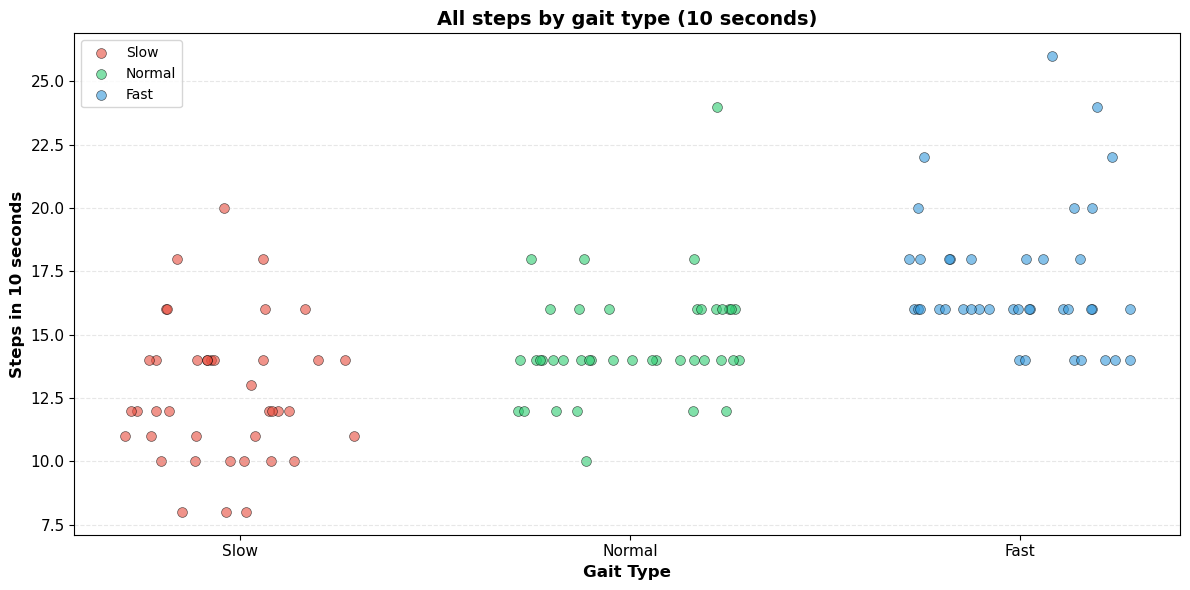


Total plotted records: 120
- Slow: 40
- Normal: 40
- Fast: 40


In [5]:
# Clean data: remove NaN and infinite values
df_clean = df[['label', 'steps_10s']].copy()
df_clean = df_clean.dropna()
df_clean = df_clean[~df_clean['steps_10s'].isin([float('inf'), float('-inf')])]

# Sort by gait type: slow, normal, fast
order = ['gait_slow', 'gait_normal', 'gait_fast']

# Create positions for each category
positions = {'gait_slow': 0, 'gait_normal': 1, 'gait_fast': 2}
df_clean['x_position'] = df_clean['label'].map(positions)

# Add small random offset to avoid overlap
import numpy as np
np.random.seed(42)
jitter = np.random.uniform(-0.3, 0.3, len(df_clean))
df_clean['x_jitter'] = df_clean['x_position'].values + jitter

# Create chart
plt.figure(figsize=(12, 6))

colors = {'gait_slow': '#e74c3c', 'gait_normal': '#2ecc71', 'gait_fast': '#3498db'}

# Plot all individual points
for label in order:
    data = df_clean[df_clean['label'] == label]
    plt.scatter(data['x_jitter'], data['steps_10s'], 
               color=colors[label], alpha=0.6, s=50, 
               label=label.replace('gait_', '').capitalize(), edgecolors='black', linewidth=0.5)

# Customize chart
plt.xlabel('Gait Type', fontsize=12, fontweight='bold')
plt.ylabel('Steps in 10 seconds', fontsize=12, fontweight='bold')
plt.title('All steps by gait type (10 seconds)', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2], ['Slow', 'Normal', 'Fast'], fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTotal plotted records: {len(df_clean)}")
print(f"- Slow: {len(df_clean[df_clean['label'] == 'gait_slow'])}")
print(f"- Normal: {len(df_clean[df_clean['label'] == 'gait_normal'])}")
print(f"- Fast: {len(df_clean[df_clean['label'] == 'gait_fast'])}")

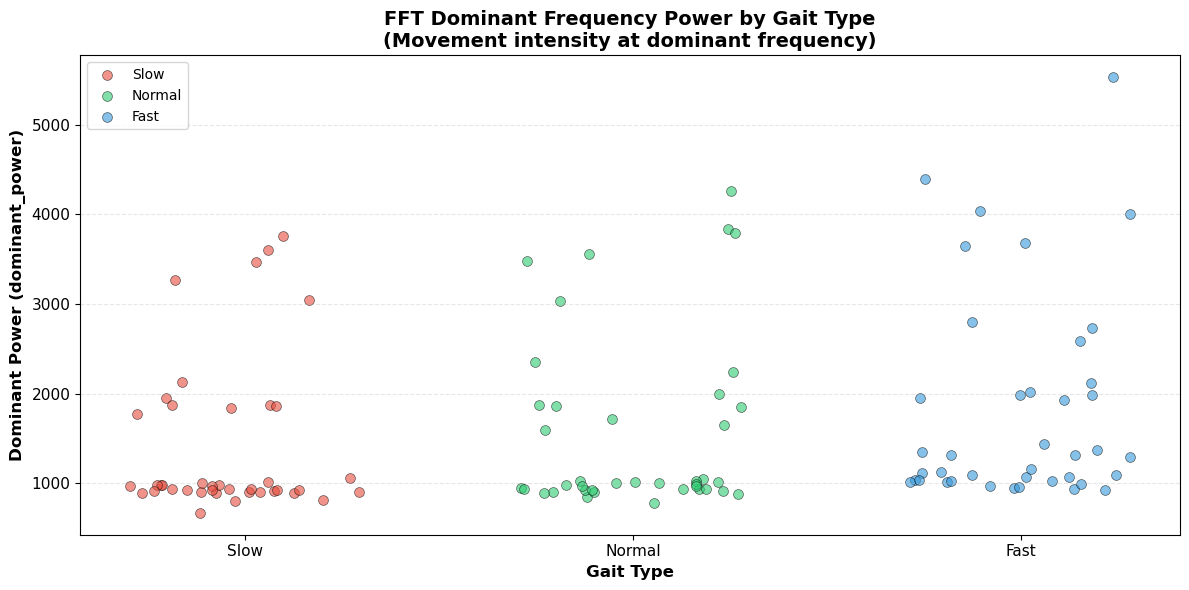


Total plotted records: 120
- Slow: 40
- Normal: 40
- Fast: 40

Dominant power statistics:
             count         mean          std         min          25%  \
label                                                                   
gait_fast     40.0  1826.169087  1164.000249  919.535711  1029.533249   
gait_normal   40.0  1570.414983   991.795173  774.991724   933.478517   
gait_slow     40.0  1406.914161   866.567883  668.198698   911.561814   

                     50%          75%          max  
label                                               
gait_fast    1302.743452  2046.155594  5533.662804  
gait_normal  1008.954872  1867.846180  4260.655428  
gait_slow     966.500442  1844.978992  3760.395351  


In [6]:
# Clean data: remove NaN and infinite values
df_clean = df[['label', 'dominant_power']].copy()
df_clean = df_clean.dropna()
df_clean = df_clean[~df_clean['dominant_power'].isin([float('inf'), float('-inf')])]

# Sort by gait type: slow, normal, fast
order = ['gait_slow', 'gait_normal', 'gait_fast']

# Create positions for each category
positions = {'gait_slow': 0, 'gait_normal': 1, 'gait_fast': 2}
df_clean['x_position'] = df_clean['label'].map(positions)

# Add small random offset to avoid overlap
import numpy as np
np.random.seed(42)
jitter = np.random.uniform(-0.3, 0.3, len(df_clean))
df_clean['x_jitter'] = df_clean['x_position'].values + jitter

# Create chart
plt.figure(figsize=(12, 6))

colors = {'gait_slow': '#e74c3c', 'gait_normal': '#2ecc71', 'gait_fast': '#3498db'}

# Plot all individual points
for label in order:
    data = df_clean[df_clean['label'] == label]
    plt.scatter(data['x_jitter'], data['dominant_power'], 
               color=colors[label], alpha=0.6, s=50, 
               label=label.replace('gait_', '').capitalize(), edgecolors='black', linewidth=0.5)

# Customize chart
plt.xlabel('Gait Type', fontsize=12, fontweight='bold')
plt.ylabel('Dominant Power (dominant_power)', fontsize=12, fontweight='bold')
plt.title('FFT Dominant Frequency Power by Gait Type\n(Movement intensity at dominant frequency)', 
         fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2], ['Slow', 'Normal', 'Fast'], fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

print(f"\nTotal plotted records: {len(df_clean)}")
print(f"- Slow: {len(df_clean[df_clean['label'] == 'gait_slow'])}")
print(f"- Normal: {len(df_clean[df_clean['label'] == 'gait_normal'])}")
print(f"- Fast: {len(df_clean[df_clean['label'] == 'gait_fast'])}")

print("\nDominant power statistics:")
print(df_clean.groupby('label')['dominant_power'].describe())

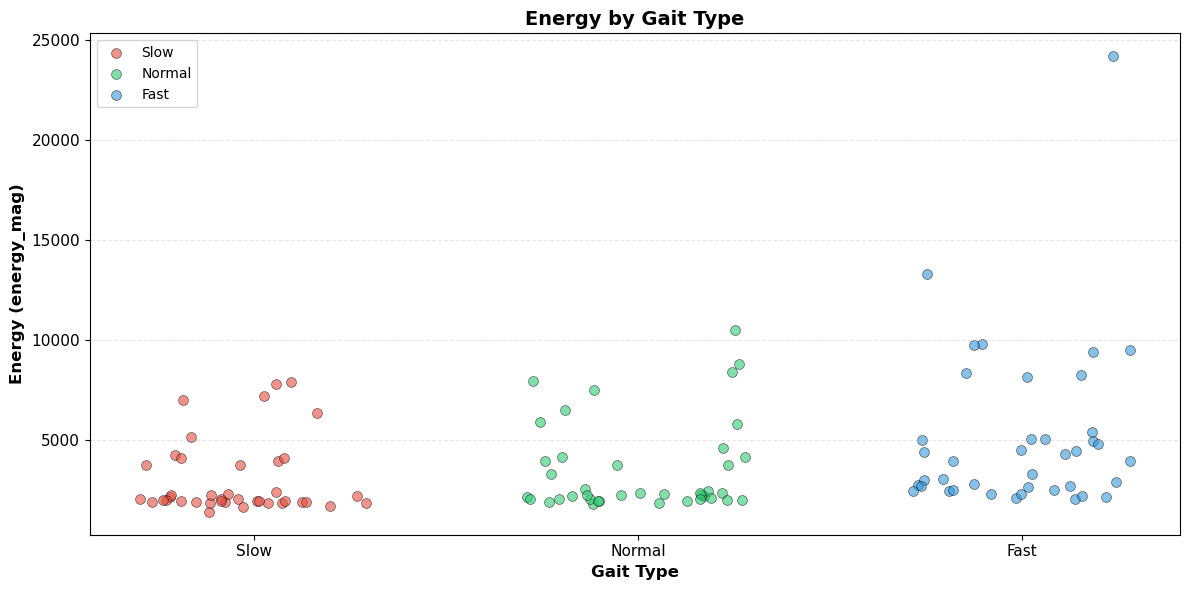


Total plotted records: 120
- Slow: 40
- Normal: 40
- Fast: 40


In [7]:
# Clean data: remove NaN and infinite values
df_clean = df[['label', 'energy_mag']].copy()
df_clean = df_clean.dropna()
df_clean = df_clean[~df_clean['energy_mag'].isin([float('inf'), float('-inf')])]

# Sort by gait type: slow, normal, fast
order = ['gait_slow', 'gait_normal', 'gait_fast']

# Create positions for each category
positions = {'gait_slow': 0, 'gait_normal': 1, 'gait_fast': 2}
df_clean['x_position'] = df_clean['label'].map(positions)

# Add small random offset to avoid overlap
import numpy as np
np.random.seed(42)
jitter = np.random.uniform(-0.3, 0.3, len(df_clean))
df_clean['x_jitter'] = df_clean['x_position'].values + jitter

# Create chart
plt.figure(figsize=(12, 6))

colors = {'gait_slow': '#e74c3c', 'gait_normal': '#2ecc71', 'gait_fast': '#3498db'}

# Plot all individual points
for label in order:
    data = df_clean[df_clean['label'] == label]
    plt.scatter(data['x_jitter'], data['energy_mag'], 
               color=colors[label], alpha=0.6, s=50, 
               label=label.replace('gait_', '').capitalize(), edgecolors='black', linewidth=0.5)

# Customize chart
plt.xlabel('Gait Type', fontsize=12, fontweight='bold')
plt.ylabel('Energy (energy_mag)', fontsize=12, fontweight='bold')
plt.title('Energy by Gait Type', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2], ['Slow', 'Normal', 'Fast'], fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nTotal plotted records: {len(df_clean)}")
print(f"- Slow: {len(df_clean[df_clean['label'] == 'gait_slow'])}")
print(f"- Normal: {len(df_clean[df_clean['label'] == 'gait_normal'])}")
print(f"- Fast: {len(df_clean[df_clean['label'] == 'gait_fast'])}")